#### AI 헬스케어 첫번째 미니 프로젝트 “흡연 여부 데이터 분석을 통한 건강 인사이트 도출” 에 오신 여러분 환영합니다.
이번 프로젝트에서는 흡연여부를 판단하는 데이터를 가지고 시각화 및 가설을 판별해보려고 합니다.


A-Z로 진행되는 만큼 천천히 따라해보세요!

#### 팀 과제
- 데이터 구조, 분포 확인, 전처리 : 1.1_흡연여부데이터
- 데이터 간 관계 가설 수립 및 검증 : 1.2_데이터분석



### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련




---



In [2]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,043 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("라이브러리 로딩 완료!")

Mounted at /content/drive
라이브러리 로딩 완료!


In [2]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
import pandas as pd
health_data = pd.read_csv("/content/drive/MyDrive/AI_health_care_4/Miniproject_1-smoking_data_analysis/smoking_health_data.csv")


# 체중 상태 추가
def health_data_bmi(bmi):
    if bmi < 18.5:
        result = '저체중'
    elif bmi < 25:
        result = '정상'
    elif bmi < 30:
        result = '과체중'
    else:
        result = '비만'
    return result

health_data['체중 상태'] = health_data['BMI'].apply(health_data_bmi)
print(health_data.head())

# 나이대 추가
def health_data_age(age):
  if age < 30:
    result = '29세 이하'
  elif age >= 30 and age < 50:
    result = '30~40대'
  elif age >=50 and age < 70:
    result = '50~60대'
  else:
    result = '70대 이상'
  return result

health_data['나이대']=health_data['나이'].apply(health_data_age)
print(health_data.head())

# fillna 결측치 채우기
for name in ['시력','혈압','공복 혈당','중성 지방']:
  health_data[name]=health_data[name].fillna(health_data.groupby('나이대')[name].transform('median'))

           ID  나이  키(cm)  몸무게(kg)    BMI    시력  충치  공복 혈당    혈압  중성 지방  \
0  TRAIN_0000  35    170       70  24.22  1.10   1   98.0  40.0   80.0   
1  TRAIN_0001  40    150       55  24.44  1.00   0  173.0  39.0  104.0   
2  TRAIN_0002  60    170       50  17.30  0.75   0   96.0  40.0   61.0   
3  TRAIN_0003  40    150       45  20.00  0.50   0   92.0  40.0   46.0   
4  TRAIN_0004  55    155       65  27.06   NaN   0   87.0  42.0   95.0   

   혈청 크레아티닌  콜레스테롤  고밀도지단백  저밀도지단백  헤모글로빈  요 단백  간 효소율  label 체중 상태  
0       1.3    211      75     120   15.9     1   1.53      1    정상  
1       0.6    251      46     184   11.8     1   1.45      0    정상  
2       0.8    144      43      89   15.3     1   1.04      0   저체중  
3       0.7    178      66     110   13.4     1   1.18      0    정상  
4       0.9    232      62     151   13.8     1   1.32      0   과체중  
           ID  나이  키(cm)  몸무게(kg)    BMI    시력  충치  공복 혈당    혈압  중성 지방  \
0  TRAIN_0000  35    170       70  24.22  1.10   1   98.0  40

In [ ]:
health_data = pd. read_csv("/content/drive/MyDrive/AI_health_care_4/Miniproject_1-smoking_data_analysis/new_health_data.csv")

In [3]:
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        7000 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     7000 non-null   float64
 8   혈압        7000 non-null   float64
 9   중성 지방     7000 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
 18  체중 상태     7000 non-null   object 
 19  나이대       7000 non-null   object 
dtypes: float64(8), int64(9), objec

### 1. 가설 수립 (인당 최소 3개)

건강 지표별로 흡연자/비흡연자 간 통계적 차이 검증

(예시)
- H₀ (귀무가설): BMI- 흡연자와 비흡연자의 평균 BMI는 같다.
- H₁ (대립가설): BMI- 흡연자와 비흡연자의 평균 BMI는 다르다.

In [ ]:
# ### 아래에 3가지의 가설을 설정해보세요.
# # 가설 1.
# 귀무가설: 충치- 흡연자와 비흡연자의 충치 비율은 같다.
# 대립가설: 충치- 흡연자와 비흡연자의 충치 비율은 다르다.
# 흡연을 하면 치아 상태가 나빠지기 때문에 연관이 있을 것으로 생각한다.

# 흡연-충치의 상관관계 가설 수립 증거
# 흡연은 유해균의 성장을 촉진 시킨다.(스트렙토코쿠스 뮤탄스, 락토바실러스, 스트렙토코구스 고르도니, 악티노마이세스, 칸디다 알비칸스)
# 유익균의 경쟁력 약화 (스트렙토코쿠스 상귀니스)
# Wu, J., Li, M., & Huang, R. (2019). The effect of smoking on caries-related microorganisms. Tobacco induced diseases, 17, 32. https://doi.org/10.18332/tid/105913

# # 가설 2.
# 귀무가설: 헤모글로빈- 흡연자와 비흡연자의 헤모글로빈 수가 같다.
# 대립가설: 헤모글로빈- 흡연자와 비흡연자의 헤모글로빈 수가 다르다.
# 산소 부족으로 인한 보상작용으로 헤모글로빈 수치가 상승할 것을 기대한다.

# 흡연-헤모글로빈의 상관관계 가설 수립 증거
# 담배 연기의 CO가 헤모글로빈에 결합하여 산소 운반에 방해가 되고 보상 작용으로 헤모글로빈 수치가 상승하게 됨.
# Malenica, M., Prnjavorac, B., Bego, T., Dujic, T., Semiz, S., Skrbo, S., Gusic, A., Hadzic, A., & Causevic, A. (2017). Effect of Cigarette Smoking on Haematological Parameters in Healthy Population. Medical archives (Sarajevo, Bosnia and Herzegovina), 71(2), 132–136. https://doi.org/10.5455/medarh.2017.71.132-136

# # 가설 3.
# 귀무가설: 간 효소율- 흡연자와 비흡연자의 효소 수치가 같다.
# 대립가설: 간 효소율- 흡연자와 비흡연자의 효소 수치가 다르다.
# 가설2의 헤모글로빈이 증가함에 따라 염증 수치가 증가할 수 있어 연관이 있다고 기대한다.
# 또한, 간의 독성물질을 해소하기 위해 해독작용이 활발해짐에 따라 간 효소율이 증가할 것으로 기대한다.

# 흡연-간 효소율의 상관관계 가설 수립 증거
# 흡연은 GGT와 ALP 수치와 유의미한 관련이 있다.
# Wannamethee, S. G., & Shaper, A. G. (2010). Cigarette smoking and serum liver enzymes: the role of alcohol and inflammation. Annals of clinical biochemistry, 47(Pt 4), 321–326. https://doi.org/10.1258/acb.2010.009303


# # 가설 4. 8~12시간 공복시간을 지키고 측정해야 하지만 본 연구에서는 수치상의 자료만으로 측정하였습니다.
# 귀무가설: 중성 지방- 흡연자와 비흡연자의 중성지방 수치가 같다.
# 대립가설: 중성 지방- 흡연자와 비흡연자의 중성지방 수치가 다르다.
# 귀무가설: 콜레스테롤- 흡연자와 비흡연자의 콜레스테롤 수치가 같다.
# 대립가설: 콜레스테롤- 흡연자와 비흡연자의 콜레스테롤 수치가 다르다.
# 귀무가설: 저밀고지단백- 흡연자와 비흡연자의 저밀도지단백 수치가 같다.
# 대립가설: 저밀고지단백- 흡연자와 비흡연자의 저밀도지단백 수치가 다르다.
# 귀무가설: 고밀고지단백- 흡연자와 비흡연자의 고밀도지단백 수치가 같다.
# 대립가설: 고밀고지단백- 흡연자와 비흡연자의 고밀도지단백 수치가 다르다.

# 담배의 니코틴이 아드레날린 분비를 촉진하고 체내 지방 조직의 지방산이 혈액으로 방출되어 높아질 것으로 기대한다.

# 중성 지방과 흡연과의 상관관계의 가설 수립 증거
# Jain, R. B., & Ducatman, A. (2018). Associations between smoking and lipid/lipoprotein concentrations among US adults aged ≥20 years. Journal of Circulating Biomarkers, 7(1). https://doi.org/10.33393/jcb.2018.2089
# 흡연자는 비흡연자에 비해 조정된 HDL 수치가 낮았으며(48.8 대 51.4 mg/dL, p < 0.01), 조정된 TG 수치는 더 높았다(124.4 대 111.9 mg/dL, p < 0.01).
# ANGPTL4가 LPL 활성을 억제하여 중성지방 수치가 증가한다. -> 간접적인 메커니즘: 흡연으로 인한 산화 스트레스와 염증 반응이 ANGPTL4 발현을 조절하는 전사 인자(예: ​PPARs, HIF-1α)에 영향을 미칠 수 있다는 간접적인 가능성은 존재한다.
# La Paglia, Laura, Listì, Angela, Caruso, Stefano, Amodeo, Valeria, Passiglia, Francesco, Bazan, Viviana, Fanale, Daniele, Potential Role of ANGPTL4 in the Cross Talk between Metabolism and Cancer through PPAR Signaling Pathway, PPAR Research, 2017, 8187235, 15 pages, 2017. https://doi.org/10.1155/2017/8187235

# HDL과 흡연과의 상관관계 가설 수립 증거 +(콜레스테롤, LDL)
# Jain, R. B., & Ducatman, A. (2018). Associations between smoking and lipid/lipoprotein concentrations among US adults aged ≥20 years. Journal of Circulating Biomarkers, 7(1). https://doi.org/10.33393/jcb.2018.2089
# 흡연이 HDL를 낮추기도 하지만 핵심 기능인 콜레스테롤 유출 능력과 항염증 능력을 저해한다.
# Kohei Takata, Satoshi Imaizumi, Emi Kawachi, Yasunori Suematsu, Tomohiko Shimizu, Satomi Abe, Yoshino Matsuo, Hitomi Tsukahara, Keita Noda, Eiji Yahiro, Bo Zhang, Yoshinari Uehara, Shin-ichiro Miura, Keijiro Saku, Impact of Cigarette Smoking Cessation on High-Density Lipoprotein Functionality, Circulation Journal, 2014, Volume 78, Issue 12, Pages 2955-2962, Released on J-STAGE November 25, 2014, Advance online publication October 16, 2014, Online ISSN 1347-4820, Print ISSN 1346-9843, https://doi.org/10.1253/circj.CJ-14-0638,

# LDL과 흡연과의 상관관계는 HDL의 수치가 낮아지고 콜레스테롤 배출은 원활히 진행되지 않는 것에서 오는 변화가 어떻게 될지 궁금해서 가설수립했다.

## 2. 단변량 분석

	단변량 분석 의미 찾기:

    •	데이터 품질(결측, 이상치) 확인

    •	모델 입력값 기준 설정

- 숫자형, 범주형
- 전처리 사항
  - NaN 존재 여부 및 조치 방안
  - 가변수화 대상여부
- 기초통계량 확인
- 분포 확인
- 위 정보로부터 파악한 비즈니스 내용 정리
- 추가 분석해볼 사항 도출

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.isnull().sum()
health_data.info()
# 체중 상태, 나이대는 object로 가변수화를 해야할지 생각해봐야할듯

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        7000 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     7000 non-null   float64
 8   혈압        7000 non-null   float64
 9   중성 지방     7000 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
 18  체중 상태     7000 non-null   object 
 19  나이대       7000 non-null   object 
dtypes: float64(8), int64(9), objec

In [4]:
def get_outliers_iqr(df, column, weight=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (weight * iqr)
    upper_bound = q3 + (weight * iqr)
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if lower_bound < 0:
      lower_bound = 0
    return outliers, lower_bound, upper_bound

# 1.5 IQR vs 3.0 IQR 비교
# 3.0의 장점으로 극단값만 제거하기에 데이터를 더 보존할 수 있고 센서, 입력, 측정 오류와 같은
# 비정상 데이터만 제거할 수 있습니다. 반대로 분석 안정성은 떨어질수 있지만 극단적인 이상치 데이터를 확인했기에
# 본 프로젝트에는 3.0을 적용하였습니다.
for col in ['헤모글로빈', '간 효소율','중성 지방','콜레스테롤','고밀도지단백','저밀도지단백']:
    outliers_15, low15, up15 = get_outliers_iqr(health_data, col)
    outliers_30, low30, up30 = get_outliers_iqr(health_data, col, weight=3.0)

    print(f'[{col}]')
    print(f'  1.5*IQR 이상치 수: {len(outliers_15)} 	 범위: {low15:.2f} ~ {up15:.2f}')
    print(f'  3.0*IQR 이상치 수: {len(outliers_30)} 	 범위: {low30:.2f} ~ {up30:.2f}')
    print('-' * 50)

[헤모글로빈]
  1.5*IQR 이상치 수: 87 	 범위: 10.45 ~ 18.85
  3.0*IQR 이상치 수: 3 	 범위: 7.30 ~ 22.00
--------------------------------------------------
[간 효소율]
  1.5*IQR 이상치 수: 135 	 범위: 0.03 ~ 2.19
  3.0*IQR 이상치 수: 27 	 범위: 0.00 ~ 3.00
--------------------------------------------------
[중성 지방]
  1.5*IQR 이상치 수: 298 	 범위: 0.00 ~ 289.00
  3.0*IQR 이상치 수: 0 	 범위: 0.00 ~ 418.00
--------------------------------------------------
[콜레스테롤]
  1.5*IQR 이상치 수: 113 	 범위: 104.00 ~ 288.00
  3.0*IQR 이상치 수: 7 	 범위: 35.00 ~ 357.00
--------------------------------------------------
[고밀도지단백]
  1.5*IQR 이상치 수: 124 	 범위: 18.50 ~ 94.50
  3.0*IQR 이상치 수: 8 	 범위: 0.00 ~ 123.00
--------------------------------------------------
[저밀도지단백]
  1.5*IQR 이상치 수: 85 	 범위: 26.00 ~ 202.00
  3.0*IQR 이상치 수: 10 	 범위: 0.00 ~ 268.00
--------------------------------------------------


In [5]:
def get_bounds_3iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (3.0 * iqr)
    upper_bound = q3 + (3.0 * iqr)
    return lower_bound, upper_bound

# 복사본 생성
health_data_cleaned = health_data.copy()

# 가설 검증 항목들
target_cols = ['헤모글로빈', '간 효소율','중성 지방','콜레스테롤','고밀도지단백','저밀도지단백']

for col in target_cols:
    low, up = get_bounds_3iqr(health_data_cleaned, col)
    # 범위 내 데이터만 남기기
    health_data_cleaned = health_data_cleaned[(health_data_cleaned[col] >= low) & (health_data_cleaned[col] <= up)]

print(f'원본 데이터 수: {len(health_data)}')
print(f'이상치 제거 후 데이터 수: {len(health_data_cleaned)}')
print(f'제거된 총 데이터 수: {len(health_data) - len(health_data_cleaned)}')

display(health_data_cleaned.head())

원본 데이터 수: 7000
이상치 제거 후 데이터 수: 6950
제거된 총 데이터 수: 50


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,체중 상태,나이대
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상,30~40대
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상,30~40대
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중,50~60대
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상,30~40대
4,TRAIN_0004,55,155,65,27.06,0.90,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중,50~60대


,인원수,비율(%)
충치,,
충치 없음,5408,77.26
충치 있음,1592,22.74


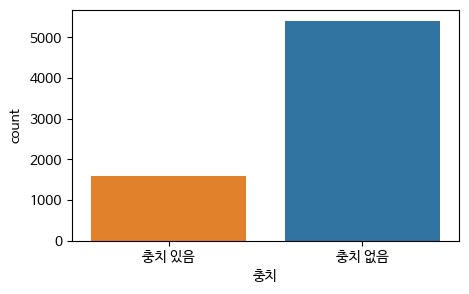

,인원수,비율(%)
충치,,
충치 없음,5367,77.22
충치 있음,1583,22.78


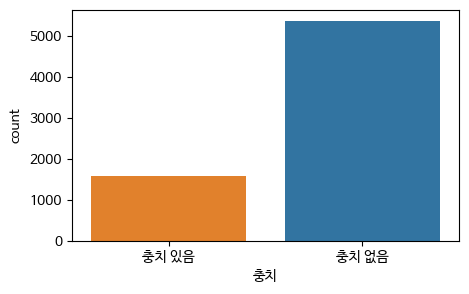

In [9]:
# @title
# 이상치 제거 X
counts = health_data['충치'].map({0:'충치 없음', 1:'충치 있음'}).value_counts()
proportions = health_data['충치'].map({0:'충치 없음', 1:'충치 있음'}).value_counts(normalize=True).mul(100).round(2)

# Combine counts and proportions into a DataFrame
result_df = pd.DataFrame({'인원수': counts, '비율(%)': proportions})
display(result_df)

plt.figure(figsize=(5,3))
sns.countplot(data=health_data, x=health_data['충치'].map({0:'충치 없음', 1:'충치 있음'}), hue='충치', legend=False)
plt.show()

# 이상치 제거 O
counts_cleaned = health_data_cleaned['충치'].map({0:'충치 없음', 1:'충치 있음'}).value_counts()
proportions_cleaned = health_data_cleaned['충치'].map({0:'충치 없음', 1:'충치 있음'}).value_counts(normalize=True).mul(100).round(2)

# Combine counts and proportions into a DataFrame
result_df_cleaned = pd.DataFrame({'인원수': counts_cleaned, '비율(%)': proportions_cleaned})
display(result_df_cleaned)

plt.figure(figsize=(5,3))
sns.countplot(data=health_data_cleaned, x=health_data_cleaned['충치'].map({0:'충치 없음', 1:'충치 있음'}), hue='충치', legend=False)
plt.show()

In [10]:
# @title
# 헤모글로빈 수치 파악
hemo=health_data['헤모글로빈'].describe()
hemo_cleaned=health_data_cleaned['헤모글로빈'].describe()
display(hemo)
display(hemo_cleaned)

,헤모글로빈
count,7000.000000
mean,14.631914
std,1.540907
min,4.900000
25%,13.600000
50%,14.800000
75%,15.700000
max,20.900000


,헤모글로빈
count,6950.000000
mean,14.641108
std,1.527522
min,7.600000
25%,13.600000
50%,14.800000
75%,15.700000
max,20.900000


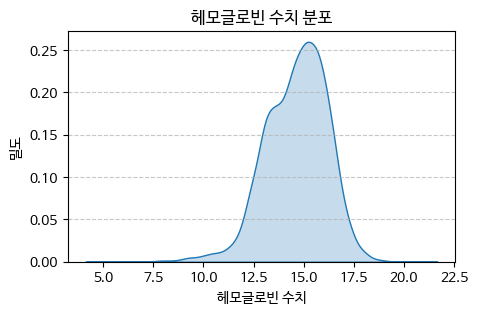

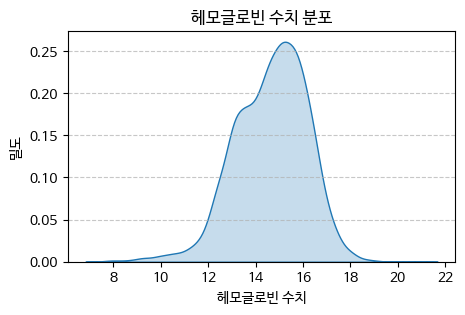

In [11]:
# @title
# 헤모글로빈 수치의 분포를 시각화 (KDE plot)
plt.figure(figsize=(5, 3))
sns.kdeplot(health_data['헤모글로빈'], fill=True)
plt.title('헤모글로빈 수치 분포')
plt.xlabel('헤모글로빈 수치')
plt.ylabel('밀도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# 이상치 제거 O
plt.figure(figsize=(5, 3))
sns.kdeplot(health_data_cleaned['헤모글로빈'], fill=True)
plt.title('헤모글로빈 수치 분포')
plt.xlabel('헤모글로빈 수치')
plt.ylabel('밀도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

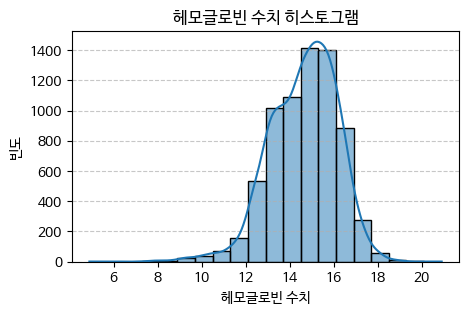

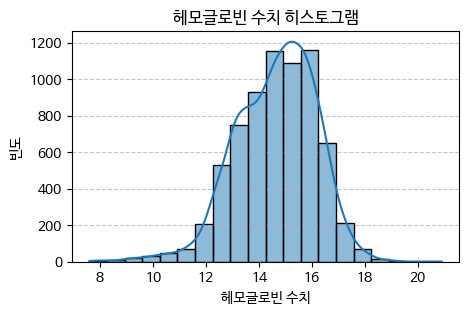

In [12]:
# @title
# 참고: 히스토그램으로 분포를 확인하는 경우
plt.figure(figsize=(5, 3))
sns.histplot(health_data['헤모글로빈'], kde=True, bins=20) # kde=True로 KDE 곡선도 함께 표시
plt.title('헤모글로빈 수치 히스토그램')
plt.xlabel('헤모글로빈 수치')
plt.ylabel('빈도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 이상치 제거 O
plt.figure(figsize=(5, 3))
sns.histplot(health_data_cleaned['헤모글로빈'], kde=True, bins=20) # kde=True로 KDE 곡선도 함께 표시
plt.title('헤모글로빈 수치 히스토그램')
plt.xlabel('헤모글로빈 수치')
plt.ylabel('빈도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
# @title
# '간 효소율'의 기초 통계 분석
liver=health_data['간 효소율'].describe()
liver_cleaned=health_data_cleaned['간 효소율'].describe()
display(liver)
display(liver_cleaned)

,간 효소율
count,7000.000000
mean,1.144696
std,0.432735
min,0.140000
25%,0.840000
50%,1.100000
75%,1.380000
max,5.670000


,간 효소율
count,6950.000000
mean,1.134413
std,0.397721
min,0.140000
25%,0.840000
50%,1.100000
75%,1.370000
max,2.980000


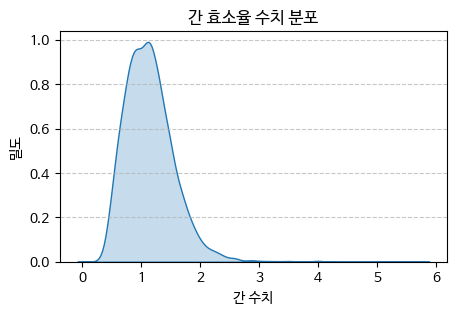

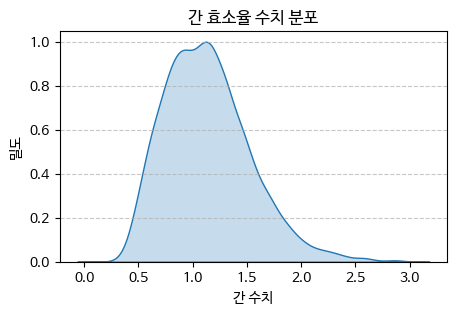

In [14]:
# @title
# 간 효소율 수치의 분포를 시각화 (KDE plot)
plt.figure(figsize=(5, 3))
sns.kdeplot(health_data['간 효소율'], fill=True)
plt.title('간 효소율 수치 분포')
plt.xlabel('간 수치')
plt.ylabel('밀도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 간 효소율 수치의 분포를 시각화 (KDE plot)
plt.figure(figsize=(5, 3))
sns.kdeplot(health_data_cleaned['간 효소율'], fill=True)
plt.title('간 효소율 수치 분포')
plt.xlabel('간 수치')
plt.ylabel('밀도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

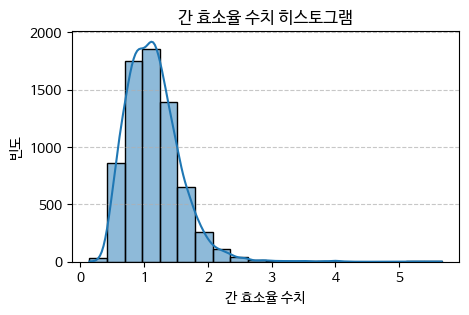

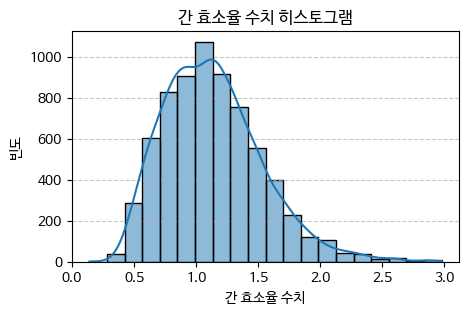

In [15]:
# @title
# 참고: 히스토그램으로 분포를 확인하는 경우
plt.figure(figsize=(5, 3))
sns.histplot(health_data['간 효소율'], kde=True, bins=20) # kde=True로 KDE 곡선도 함께 표시
plt.title('간 효소율 수치 히스토그램')
plt.xlabel('간 효소율 수치')
plt.ylabel('빈도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(5, 3))
sns.histplot(health_data_cleaned['간 효소율'], kde=True, bins=20) # kde=True로 KDE 곡선도 함께 표시
plt.title('간 효소율 수치 히스토그램')
plt.xlabel('간 효소율 수치')
plt.ylabel('빈도')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

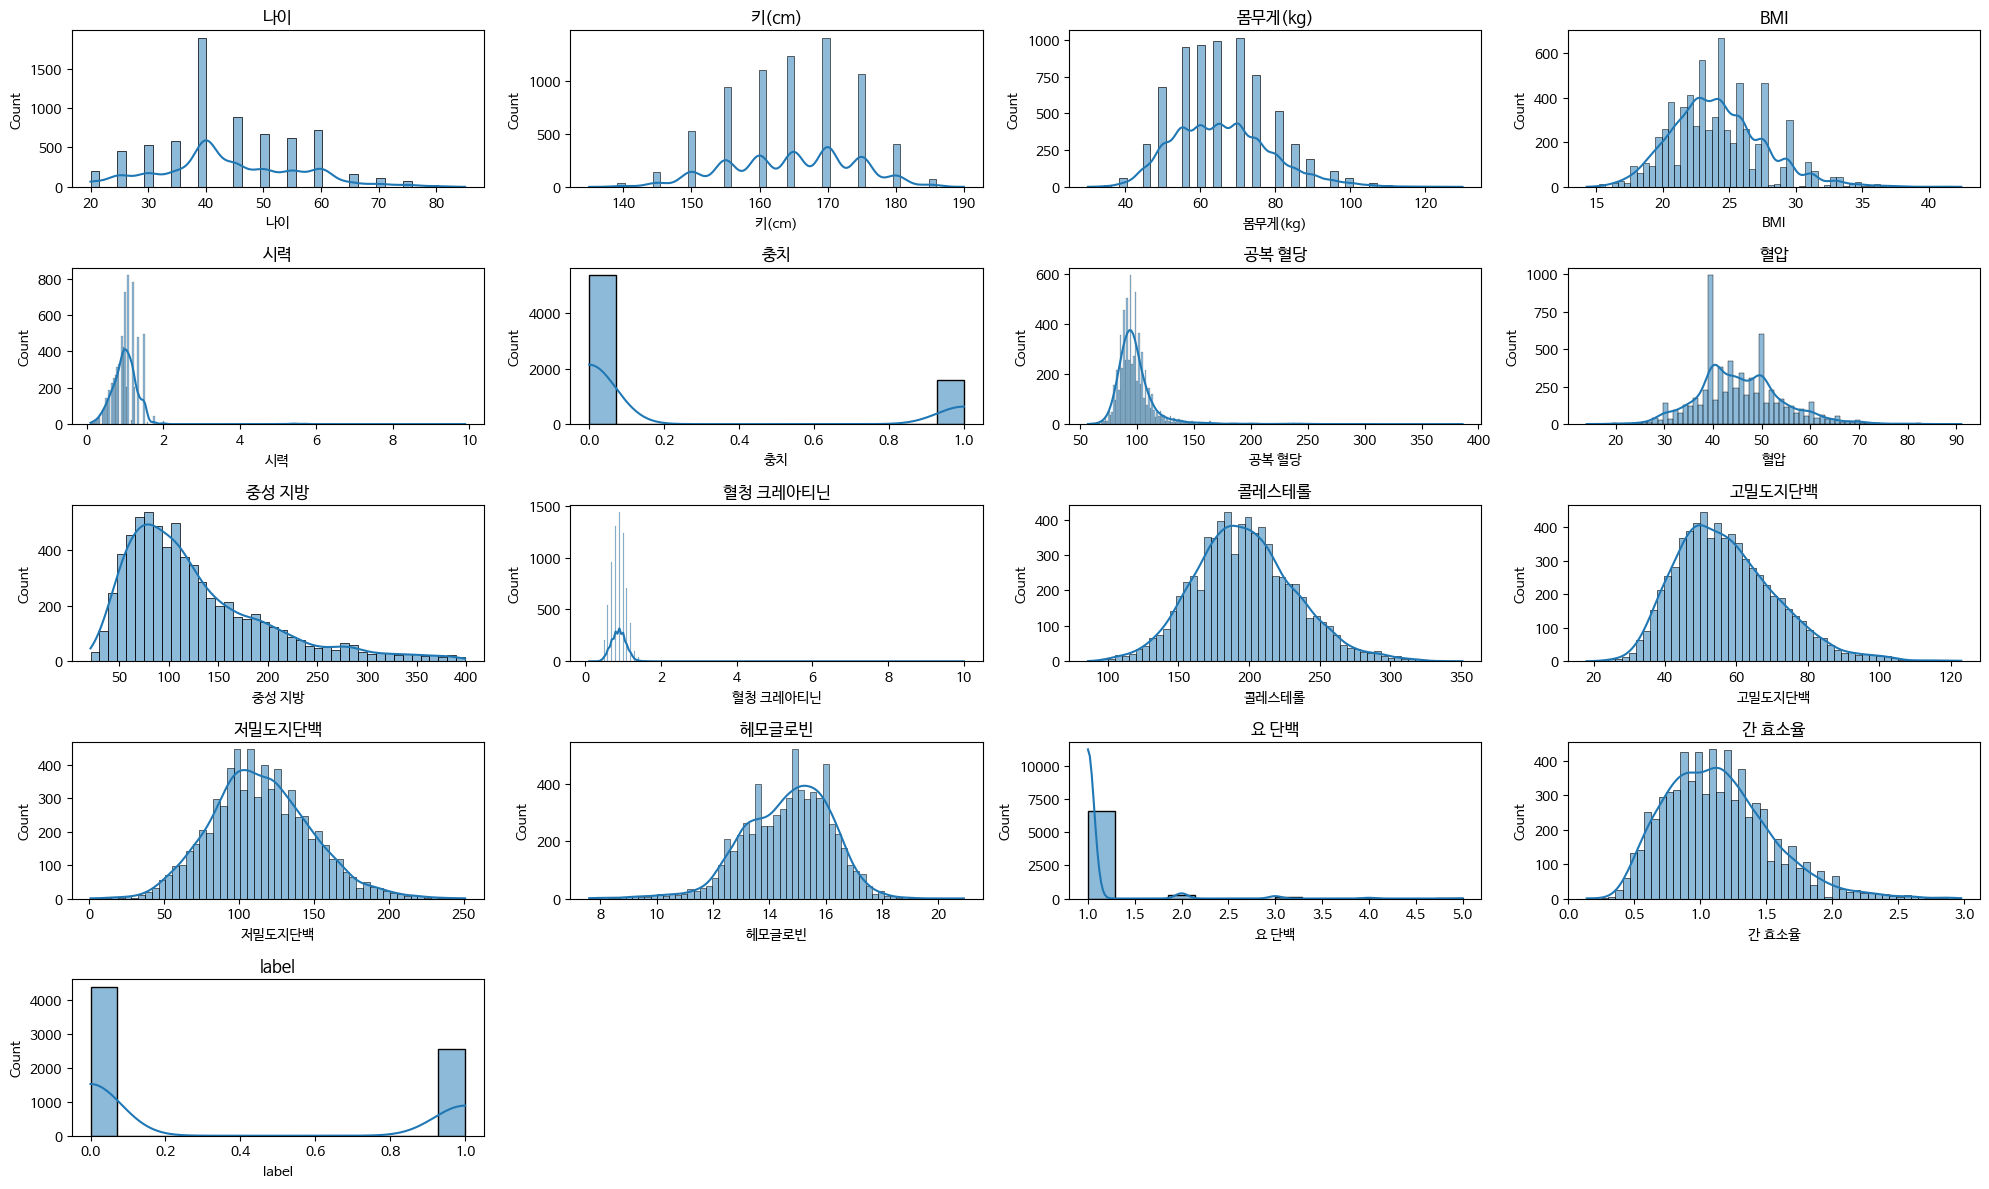

In [8]:
## [데이터 분포 확인]
num_cols = health_data_cleaned.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,12))

for i,col in enumerate(num_cols):
    plt.subplot(5,4,i+1)
    sns.histplot(health_data_cleaned[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
### 단변량 분석에서 파악한 내용을 정리해보세요.
# 헤모글로빈 수치와 간 효소율 수치 모두 이상적인 정규분포 곡선을 그리지 않는다.
# 충치는 약 77퍼의 사람이 없고, 약 23%는 충치가 있다. 둘의 값이 3배 이상 차이가 나서 단순 비교를 하면 값이 이상해지므로 비율로 보는것이 좋아보인다.

### 단변량 분석에서 파악한 내용을 정리해보세요.
1. 몸무게
 - 비흡연자의 몸무게가 흡연자 몸무게 보다 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
2. BMI
 - 비흡연자의 몸무게가 흡연자 몸무게 보다 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
3. 공복혈당
 - 비흡연자의 공복혈당이 흡연자 공복혈당보다 낮음
 - 비흡연자의 중앙값이 흡연자보다 2정도 낮음
 - 흡연자의 표준편차값이 비흡연자보다 약 10정도 높음.<br>
  => 흡연자의 공복혈당 값의 개인차가 더 큼.<br>
  => 흡연자 값들 중 이상치 값이 존재
4. 혈압
 - 비흡연자와 흡연자의 평균 혈압차이가 매우 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
5. 중성지방
 - 흡연자가 비흡연자보다 중성지방 평균이 높음
 - 두 그룹 모두 중앙값이 평균보다 낮음.
 - 흡연자의 표준편차값이 비흡연자보다 높음.<br>
 => 흡연자의 중성지방 값의 개인차가 더 큼.<br>
 => 흡연자 값들 중 이상치 값이 존재
6. 혈청cr
 - 비흡연자의 혈청Cr 흡연자보다 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 비흡연자의 표준편차값이 비흡연자보다 약 10정도 높음.
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
7. 콜레스테롤
 - 비흡연자의 콜레스테롤이 흡연자보다 높음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
8. HDL, LDL
 - 비흡연자의 HDL & LDL이 흡연자보다 높음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
9. Hb
 - 비흡연자의 수치가 흡연자보다 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
10.요단백
 - 비흡연자와 흡연자의 평균 혈압차이가 매우 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사
11. 간 효소율
 - 비흡연자와 흡연자의 평균 혈압차이가 매우 낮음
 - 평균 및 중앙값의 차이가 거의 없음
 - 흡연 여부와 상관없이 몸무게의 개인차는 두 그룹 모두 유사

## 3.이변량 분석
	이변량 분석 의미 찾기:

    •	변수 간 원인–결과 관계 탐색

    •	어떤 요인이 가장 큰 영향을 주는지 도출

    •	향후 예측 모델 설계 시 주요 Feature 후보 선별

- 가설검정시 다음의 항목을 참조하여 수행합니다.
  - 유의수준 : 5%
  - 숫자 --> 숫자 : 상관분석
  - 범주 --> 범주 : 카이제곱검정
  - 범주 --> 숫자 : t검정, 분산분석
  - 숫자 --> 범주 : 로지스틱 회귀모형을 통해, 회귀계수의 P.value로 검정을 수행합니다.

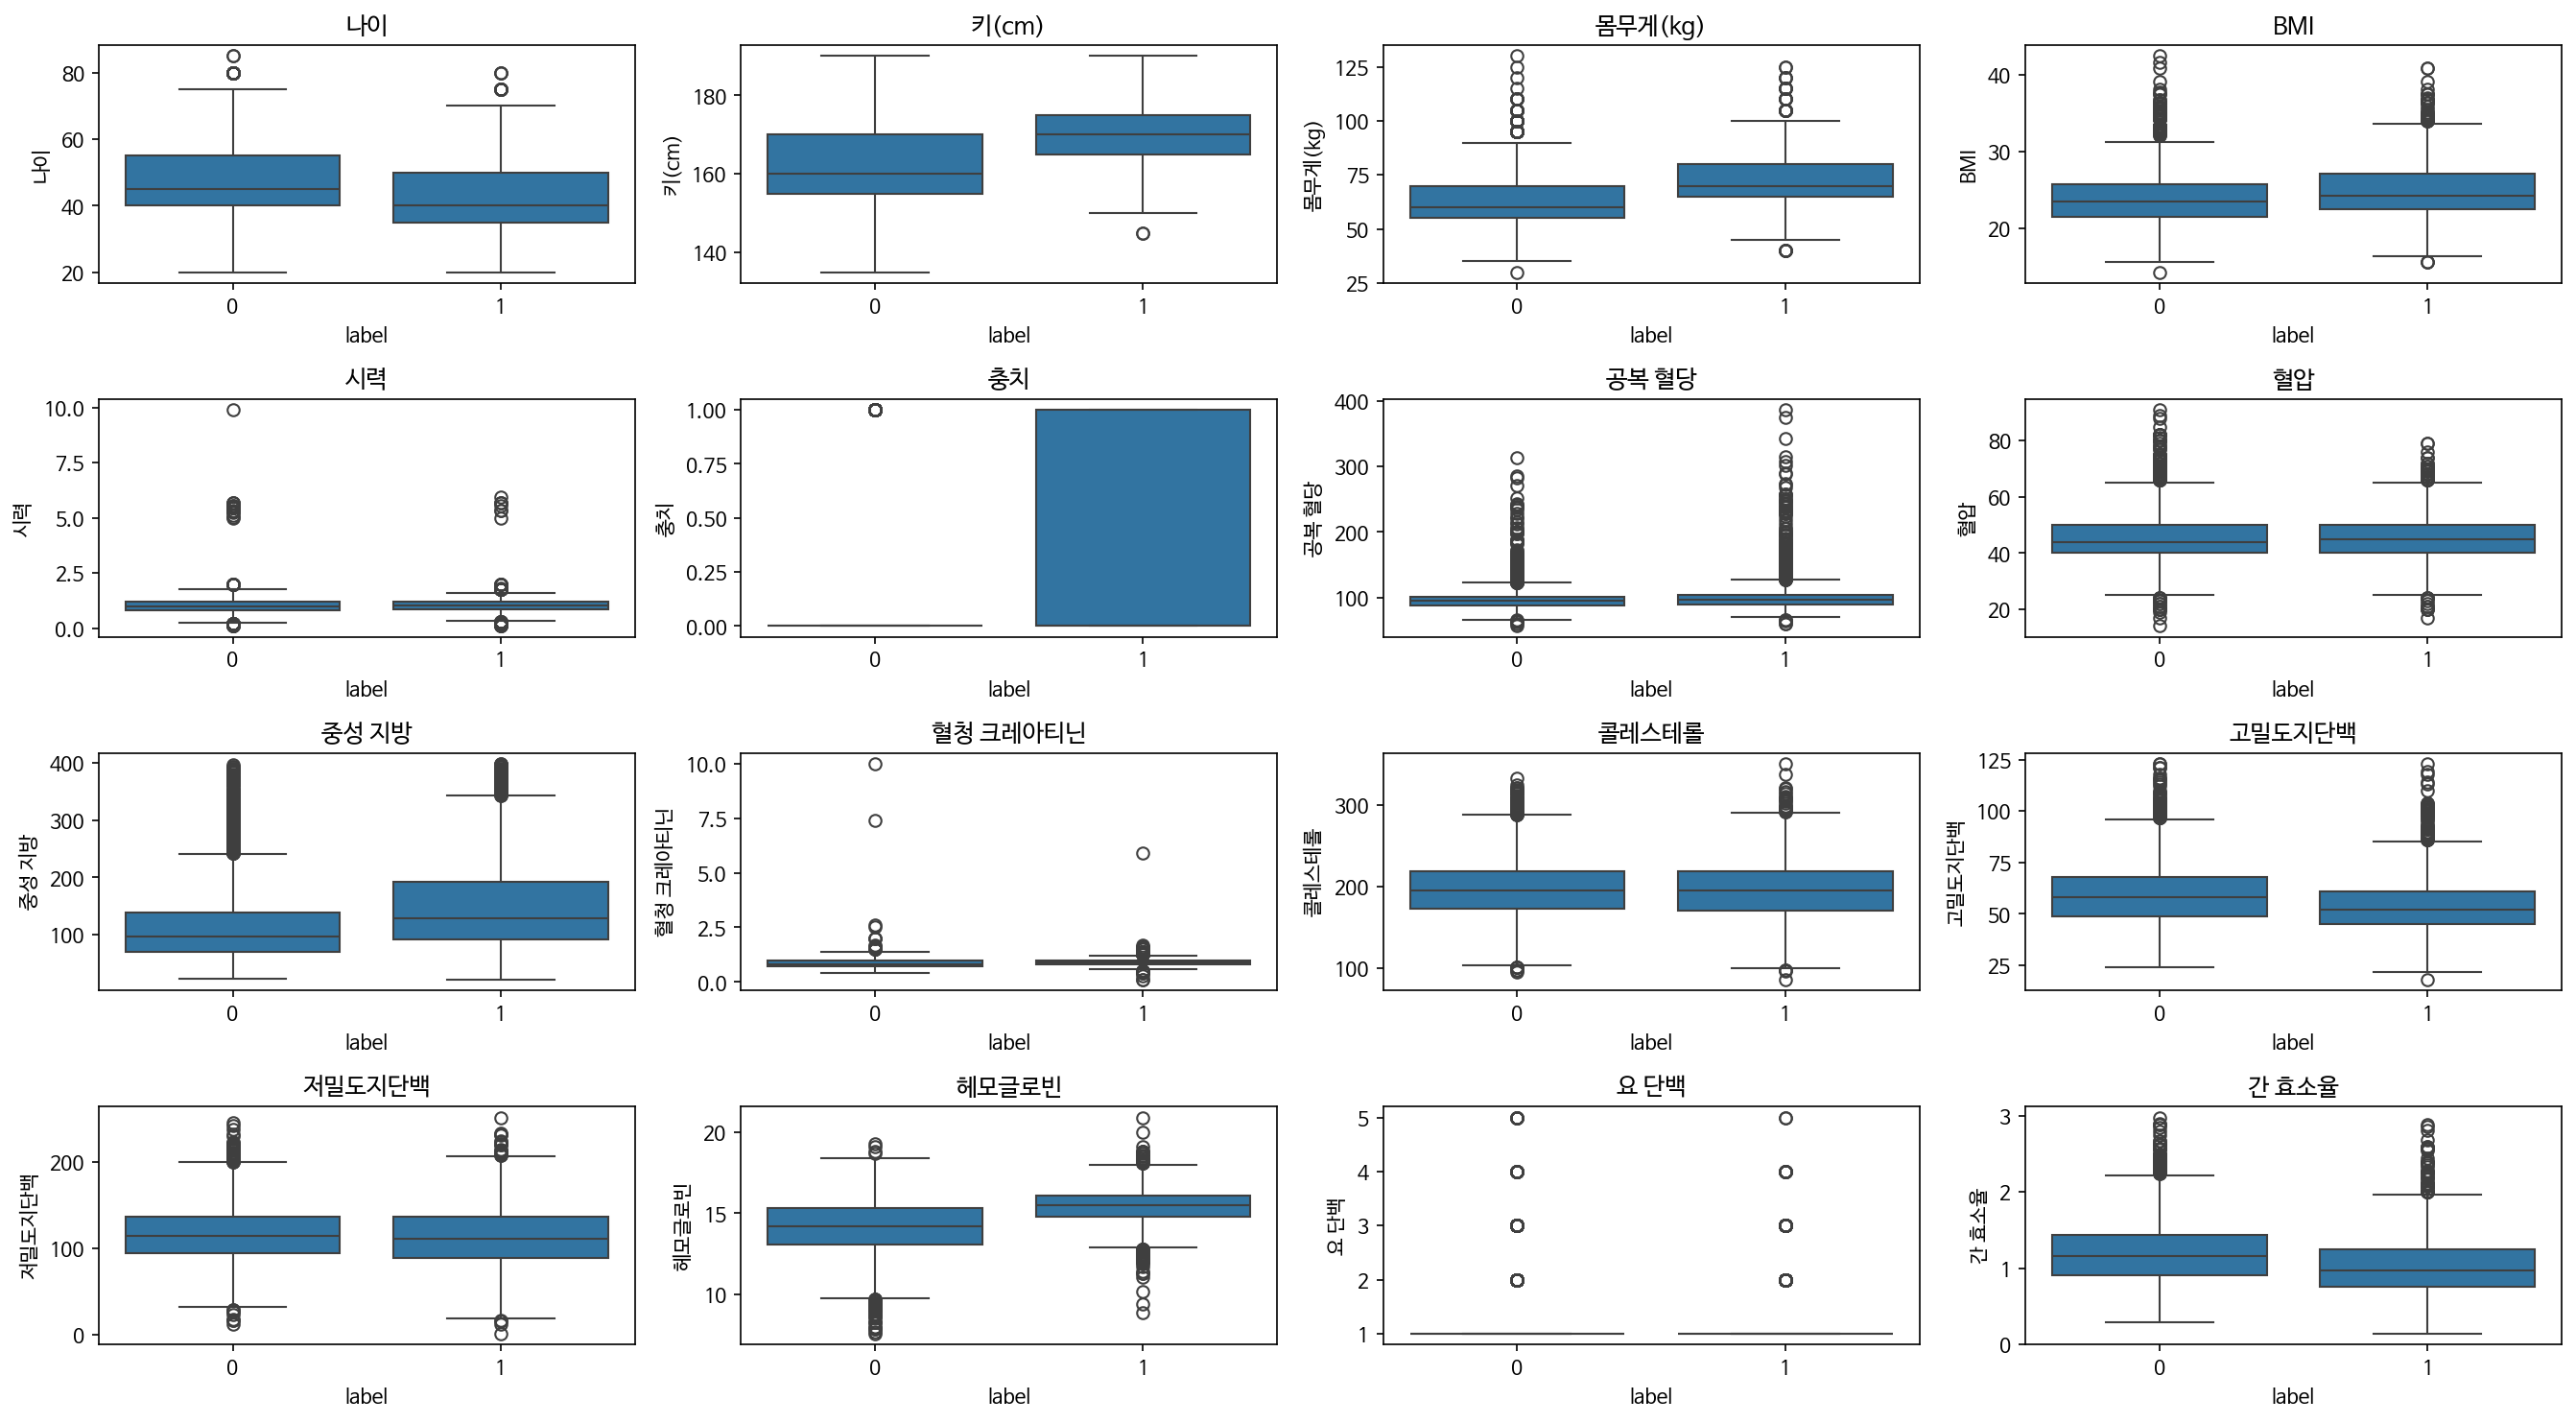

In [43]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연 여부 기준 분포
plt.figure(figsize=(18,12))

for i,col in enumerate(num_cols):
    if col != 'label':
        plt.subplot(5,4,i+1)
        sns.boxplot(x='label', y=col, data=health_data_cleaned)
        plt.title(col)

plt.tight_layout()
plt.show()

### 가설 1.
(귀무가설): 흡연 여부와 충치 발생은 서로 독립적이다.<p>
(대립가설): 흡연 여부화 충치 발생은 서로 관련이 있다.<p>
(검정방법): label, 충치 컬럼 모두 범주형 변수이므로 '카이제곱검정' 사용

In [19]:
from scipy import stats
from scipy.stats import chi2_contingency

# 1. 교차표(Contingency Table) 생성
table = pd.crosstab(health_data['충치'], health_data['label'])
print("교차표:")
display(table)

# 2. 카이제곱검정 수행
chi2, p_val, dof, expected = chi2_contingency(table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\n결론: p-value가 0.05보다 작으므로, 충치 여부와 흡연 여부 사이에는 통계적으로 유의미한 관계가 있습니다. (귀무가설 기각)")
else:
    print("\n결론: p-value가 0.05보다 크므로, 충치 여부와 흡연 여부 사이의 관계는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

# 1. 교차표(Contingency Table) 생성
table_cleaned = pd.crosstab(health_data_cleaned['충치'], health_data_cleaned['label'])
print("교차표:")
display(table_cleaned)

# 2. 카이제곱검정 수행
chi2_cleaned, p_val_cleaned, dof_cleaned, expected_cleaned = chi2_contingency(table_cleaned)

print(f"\nChi-square statistic: {chi2_cleaned:.4f}")
print(f"p-value: {p_val_cleaned:.4f}")

if p_val_cleaned < 0.05:
    print("\n결론: p-value가 0.05보다 작으므로, 충치 여부와 흡연 여부 사이에는 통계적으로 유의미한 관계가 있습니다. (귀무가설 기각)")
else:
    print("\n결론: p-value가 0.05보다 크므로, 충치 여부와 흡연 여부 사이의 관계는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

교차표:


label,0,1
충치,,
0,3561,1847
1,868,724



Chi-square statistic: 67.3857
p-value: 0.0000

결론: p-value가 0.05보다 작으므로, 충치 여부와 흡연 여부 사이에는 통계적으로 유의미한 관계가 있습니다. (귀무가설 기각)
교차표:


label,0,1
충치,,
0,3531,1836
1,862,721



Chi-square statistic: 67.0797
p-value: 0.0000

결론: p-value가 0.05보다 작으므로, 충치 여부와 흡연 여부 사이에는 통계적으로 유의미한 관계가 있습니다. (귀무가설 기각)


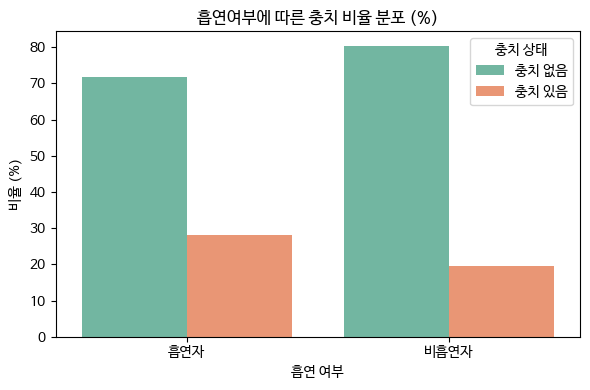

In [26]:
# 데이터 준비: 충치 비율 계산 후 100을 곱해 %로 변환
order=['흡연자','비흡연자']
caries_melted = health_data_cleaned.groupby(health_data_cleaned['label'].map({0:'비흡연자', 1:'흡연자'}))['충치'].value_counts(normalize=True).rename('비율').reset_index()
caries_melted['비율'] = caries_melted['비율'] * 100
caries_melted['충치_label'] = caries_melted['충치'].map({0: '충치 없음', 1: '충치 있음'})

plt.figure(figsize=(6, 4))
sns.barplot(data=caries_melted, x='label', y='비율', hue='충치_label', order=order, palette='Set2')

plt.title('흡연여부에 따른 충치 비율 분포 (%)')
plt.xlabel('흡연 여부')
plt.ylabel('비율 (%)')
plt.legend(title='충치 상태')
plt.tight_layout()
plt.show()

### 가설 2.
(귀무가설): 흡연 여부와 헤모글로빈은 서로 독립적이다.<p>
(대립가설): 흡연 여부화 헤모글로빈은 서로 관련이 있다.<p>
(검정방법): label, 헤모글로빈은 컬럼 범주형-숫자형 변수이므로 't검정' 사용

In [21]:
# 흡연자와 비흡연자 데이터 분리
smoker_hemo = health_data[health_data['label'] == 1]['헤모글로빈']
non_smoker_hemo = health_data[health_data['label'] == 0]['헤모글로빈']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_hemo, non_smoker_hemo)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

# 흡연자와 비흡연자 데이터 분리
smoker_hemo_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['헤모글로빈']
non_smoker_hemo_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['헤모글로빈']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_hemo_cleaned, non_smoker_hemo_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value_cleaned < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: 36.7274
p-value: 0.0000
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)
t-statistic: 36.8097
p-value: 0.0000
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 헤모글로빈 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)


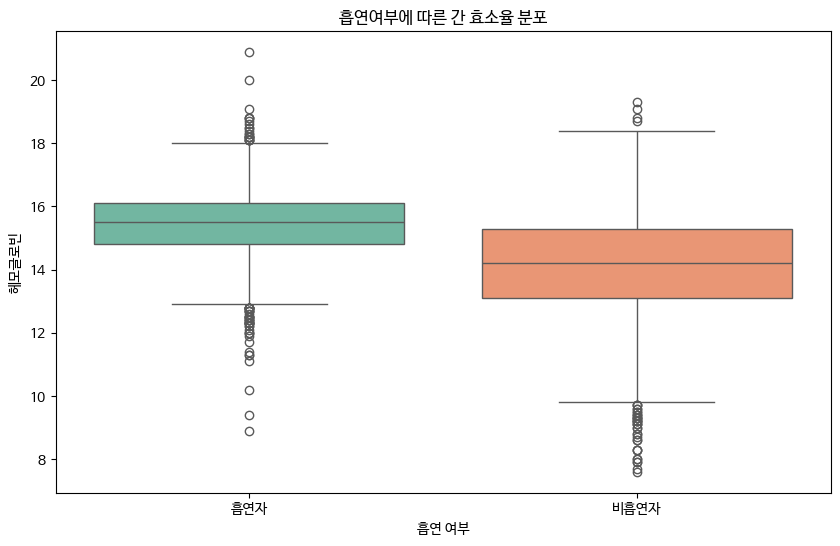

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=health_data_cleaned['label'].map({0:'비흡연자', 1:'흡연자'}), y='헤모글로빈', hue=health_data_cleaned['label'].map({0:'비흡연자', 1:'흡연자'}), data=health_data_cleaned, palette='Set2')

plt.title('흡연여부에 따른 간 효소율 분포')
plt.xlabel('흡연 여부')
plt.ylabel('헤모글로빈')
plt.show()

### 가설 3.
(귀무가설): 흡연 여부와 간 효소율은 서로 독립적이다.<p>
(대립가설): 흡연 여부화 간 효소율은 서로 관련이 있다.<p>
(검정방법): label, 간 효소율은 컬럼 범주형-숫자형 변수이므로 't검정' 사용

In [23]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연자와 비흡연자 데이터 분리
smoker_liver = health_data[health_data['label'] == 1]['간 효소율']
non_smoker_liver = health_data[health_data['label'] == 0]['간 효소율']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_liver, non_smoker_liver)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 흡연자와 비흡연자 데이터 분리
smoker_liver_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['간 효소율']
non_smoker_liver_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['간 효소율']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_liver_cleaned, non_smoker_liver_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 간 효소율 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 간 효소율 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: -15.6402
p-value: 0.0000
t-statistic: -16.7674
p-value: 0.0000
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 간 효소율 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)


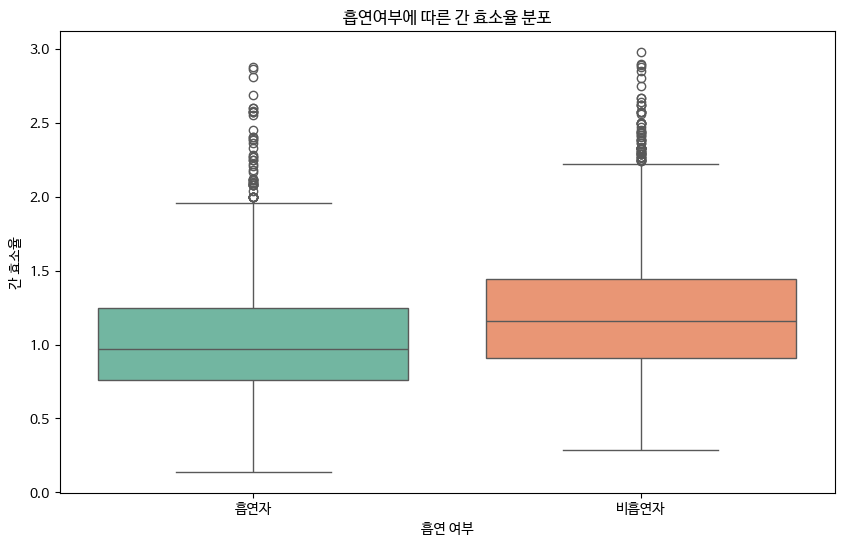

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=health_data_cleaned['label'].map({0:'비흡연자', 1:'흡연자'}), y='간 효소율', hue=health_data_cleaned['label'].map({0:'비흡연자', 1:'흡연자'}), data=health_data_cleaned, palette='Set2')

plt.title('흡연여부에 따른 간 효소율 분포')
plt.xlabel('흡연 여부')
plt.ylabel('간 효소율')
plt.show()

### 가설 4.
(귀무가설): 흡연 여부와 지질혈액검사(중성 지방, 콜레스테롤, LDL, HDL)은 서로 독립적이다.<p>
(대립가설): 흡연 여부화 지질혈액검사(중성 지방, 콜레스테롤, LDL, HDL)은 서로 관련이 있다.<p>
(검정방법): label, 지질혈액검사(중성 지방, 콜레스테롤, LDL, HDL)은 컬럼 범주형-숫자형 변수이므로 't검정' 사용

In [33]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연자와 비흡연자 데이터 분리
smoker_fat = health_data[health_data['label'] == 1]['중성 지방']
non_smoker_fat = health_data[health_data['label'] == 0]['중성 지방']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_fat, non_smoker_fat)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 흡연자와 비흡연자 데이터 분리
smoker_fat_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['중성 지방']
non_smoker_fat_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['중성 지방']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_fat_cleaned, non_smoker_fat_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 중성 지방 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 중성 지방 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: 21.1677
p-value: 0.0000
t-statistic: 21.0552
p-value: 0.0000
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 중성 지방 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)


In [34]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연자와 비흡연자 데이터 분리
smoker_col = health_data[health_data['label'] == 1]['콜레스테롤']
non_smoker_col = health_data[health_data['label'] == 0]['콜레스테롤']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_col, non_smoker_col)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 흡연자와 비흡연자 데이터 분리
smoker_col_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['콜레스테롤']
non_smoker_col_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['콜레스테롤']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_col_cleaned, non_smoker_col_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 콜레스테롤 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 콜레스테롤 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: -0.7676
p-value: 0.4427
t-statistic: -0.7435
p-value: 0.4572
결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 콜레스테롤 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)


In [35]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연자와 비흡연자 데이터 분리
smoker_ldl = health_data[health_data['label'] == 1]['저밀도지단백']
non_smoker_ldl = health_data[health_data['label'] == 0]['저밀도지단백']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_ldl, non_smoker_ldl)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 흡연자와 비흡연자 데이터 분리
smoker_ldl_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['저밀도지단백']
non_smoker_ldl_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['저밀도지단백']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_ldl_cleaned, non_smoker_ldl_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 저밀도지단백 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 저밀도지단백 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: -2.7393
p-value: 0.0062
t-statistic: -3.2496
p-value: 0.0012
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 저밀도지단백 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)


In [36]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연자와 비흡연자 데이터 분리
smoker_hdl = health_data[health_data['label'] == 1]['고밀도지단백']
non_smoker_hdl = health_data[health_data['label'] == 0]['고밀도지단백']

# t-검정 수행
t_stat, p_value = stats.ttest_ind(smoker_hdl, non_smoker_hdl)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 흡연자와 비흡연자 데이터 분리
smoker_hdl_cleaned = health_data_cleaned[health_data_cleaned['label'] == 1]['고밀도지단백']
non_smoker_hdl_cleaned = health_data_cleaned[health_data_cleaned['label'] == 0]['고밀도지단백']

# t-검정 수행
t_stat_cleaned, p_value_cleaned = stats.ttest_ind(smoker_hdl_cleaned, non_smoker_hdl_cleaned)

print(f't-statistic: {t_stat_cleaned:.4f}')
print(f'p-value: {p_value_cleaned:.4f}')

if p_value < 0.05:
    print("결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 고밀도지단백 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)")
else:
    print("결론: p-value가 0.05보다 크므로, 흡연자와 비흡연자의 고밀도지단백 수치 평균 차이는 통계적으로 유의미하지 않습니다. (귀무가설 채택)")

t-statistic: -15.3812
p-value: 0.0000
t-statistic: -15.4321
p-value: 0.0000
결론: p-value가 0.05보다 작으므로, 흡연자와 비흡연자의 고밀도지단백 수치 평균은 통계적으로 유의미한 차이가 있습니다. (귀무가설 기각)


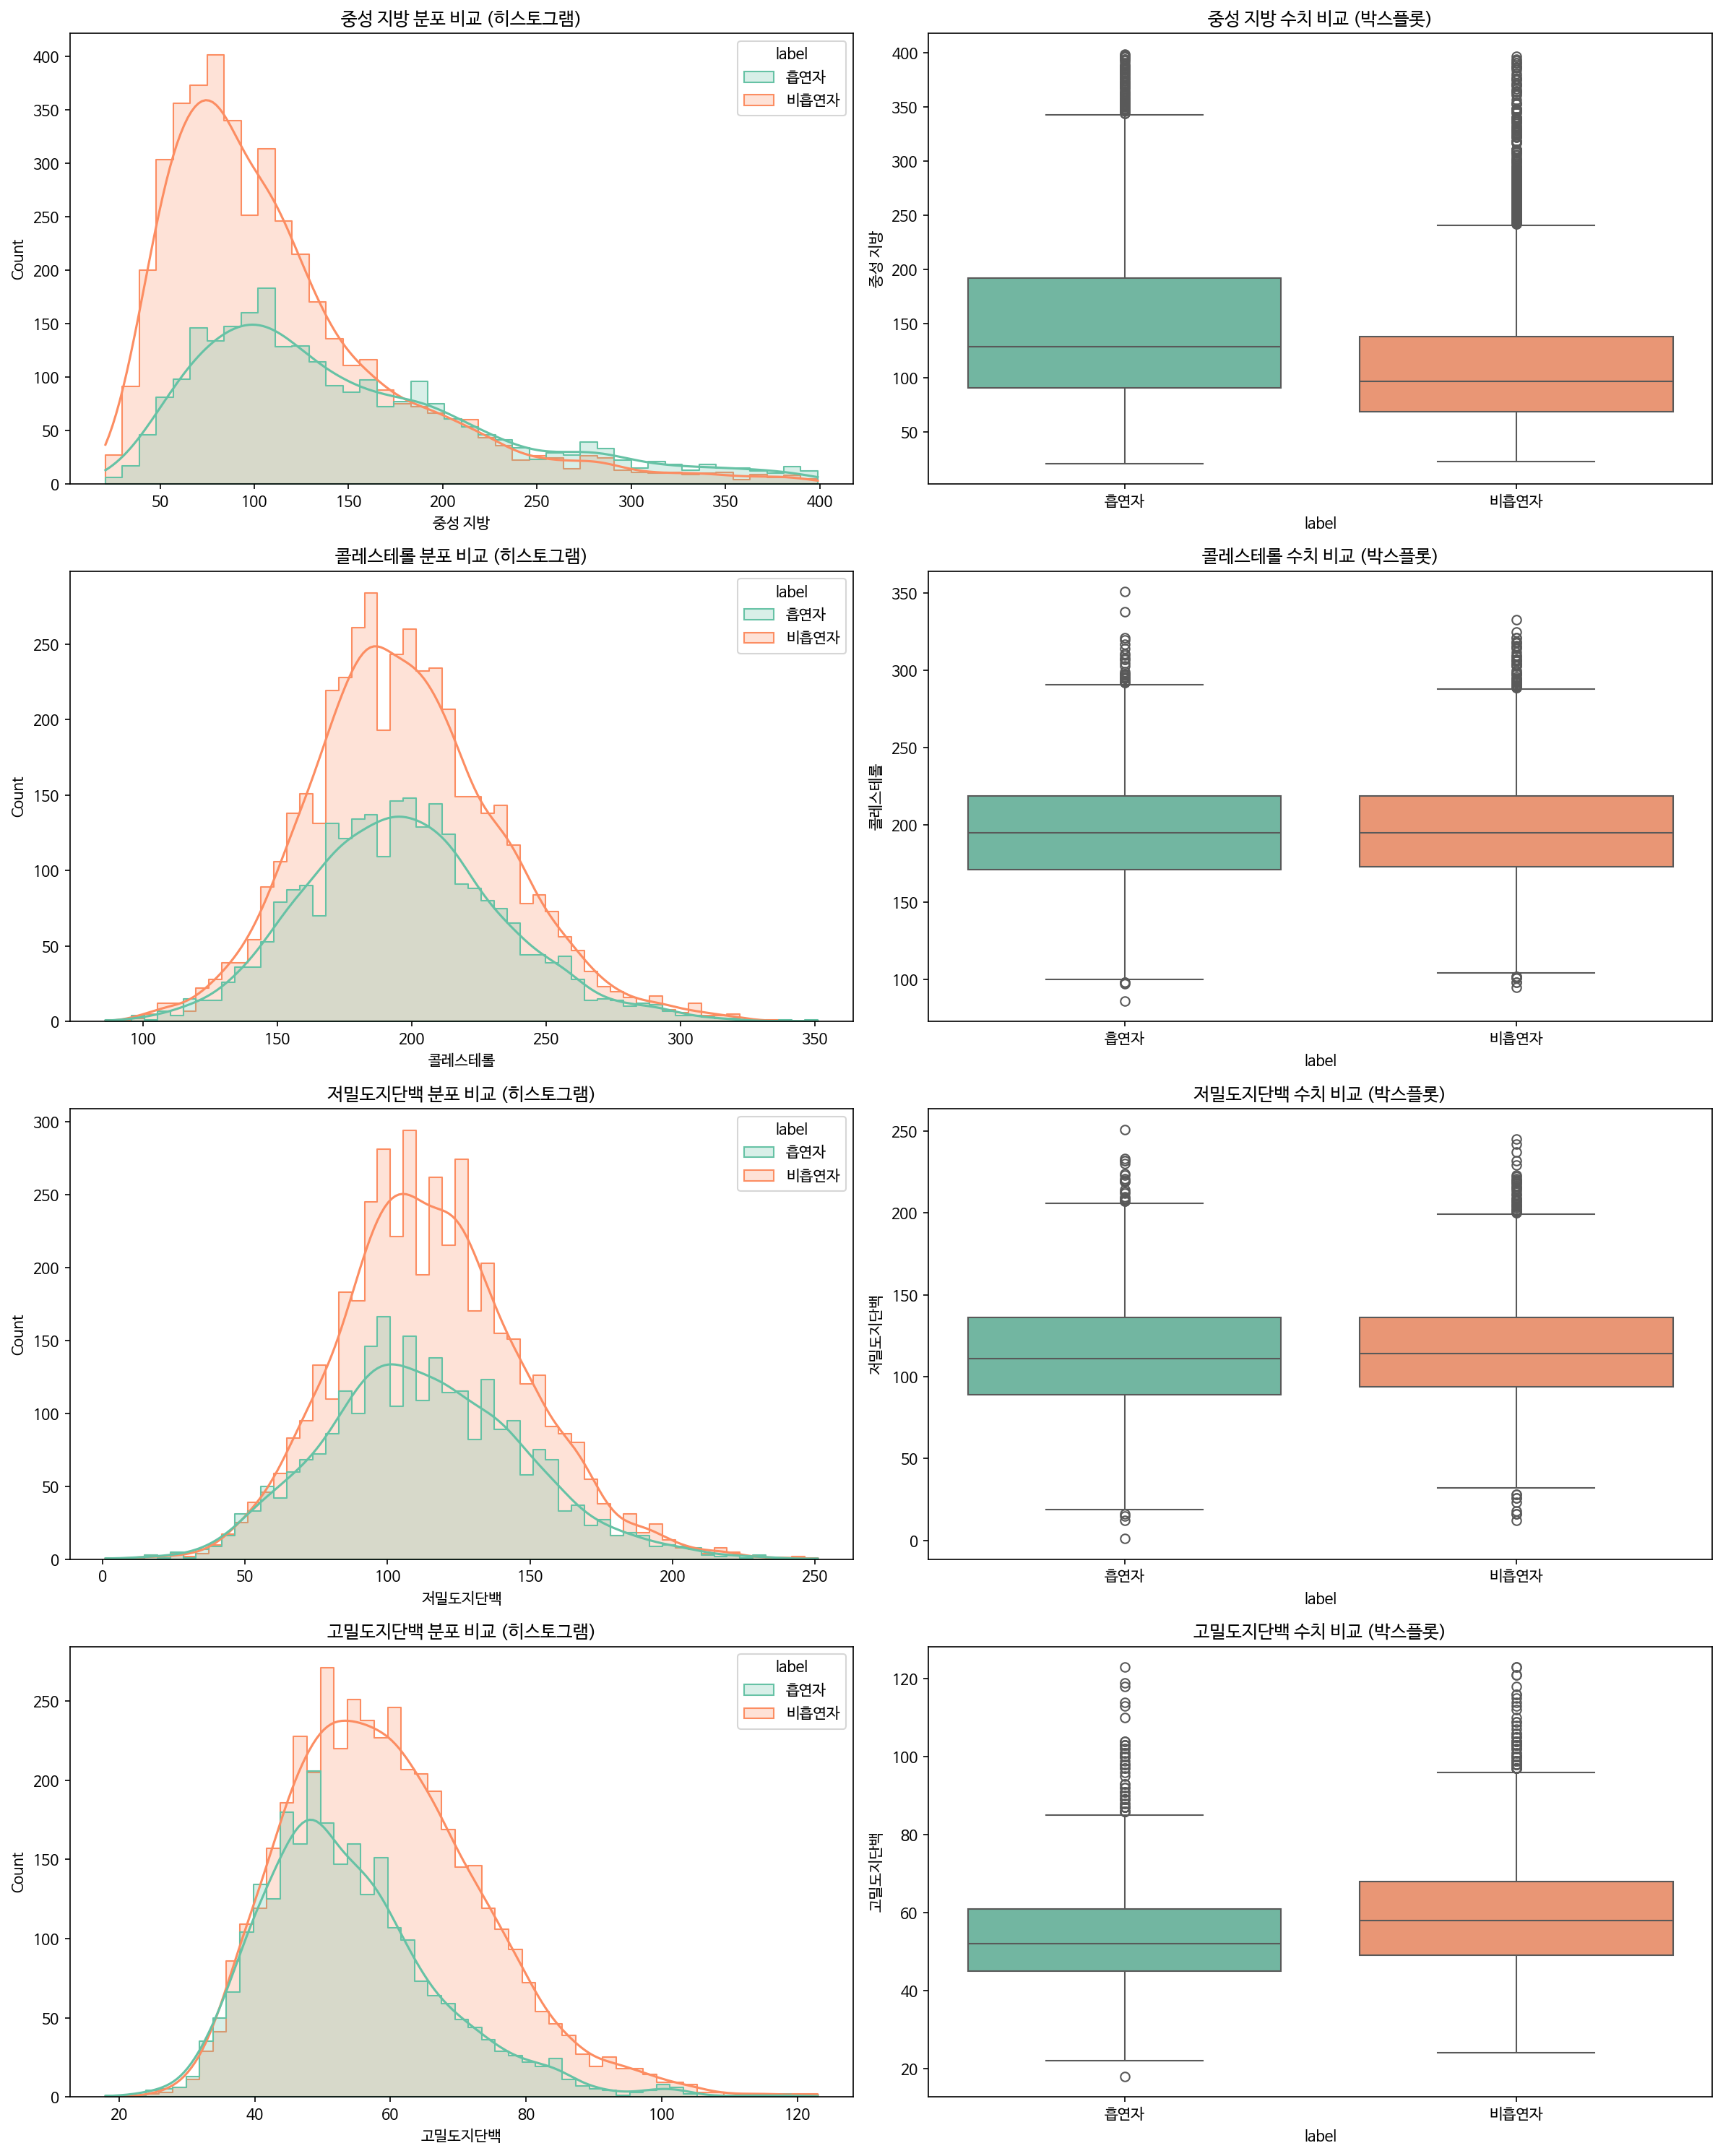

In [38]:
# count만
# 분석할 지표 리스트
target_metrics = ['중성 지방', '콜레스테롤', '저밀도지단백', '고밀도지단백']
label_map = {0: '비흡연자', 1: '흡연자'}

# 4행 2열 레이아웃 설정 (각 지표별 히스토그램 + 박스플롯)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, metric in enumerate(target_metrics):
    # 1. 히스토그램 (왼쪽 열)
    sns.histplot(data=health_data_cleaned, x=metric, hue=health_data_cleaned['label'].map(label_map),
                 kde=True, element='step', ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'{metric} 분포 비교 (히스토그램)')

    # 2. 박스플롯 (오른쪽 열)
    sns.boxplot(data=health_data_cleaned, x=health_data_cleaned['label'].map(label_map), y=metric,
                hue=health_data['label'].map(label_map), palette='Set2', ax=axes[i, 1], legend=False)
    axes[i, 1].set_title(f'{metric} 수치 비교 (박스플롯)')

plt.tight_layout()
plt.show()

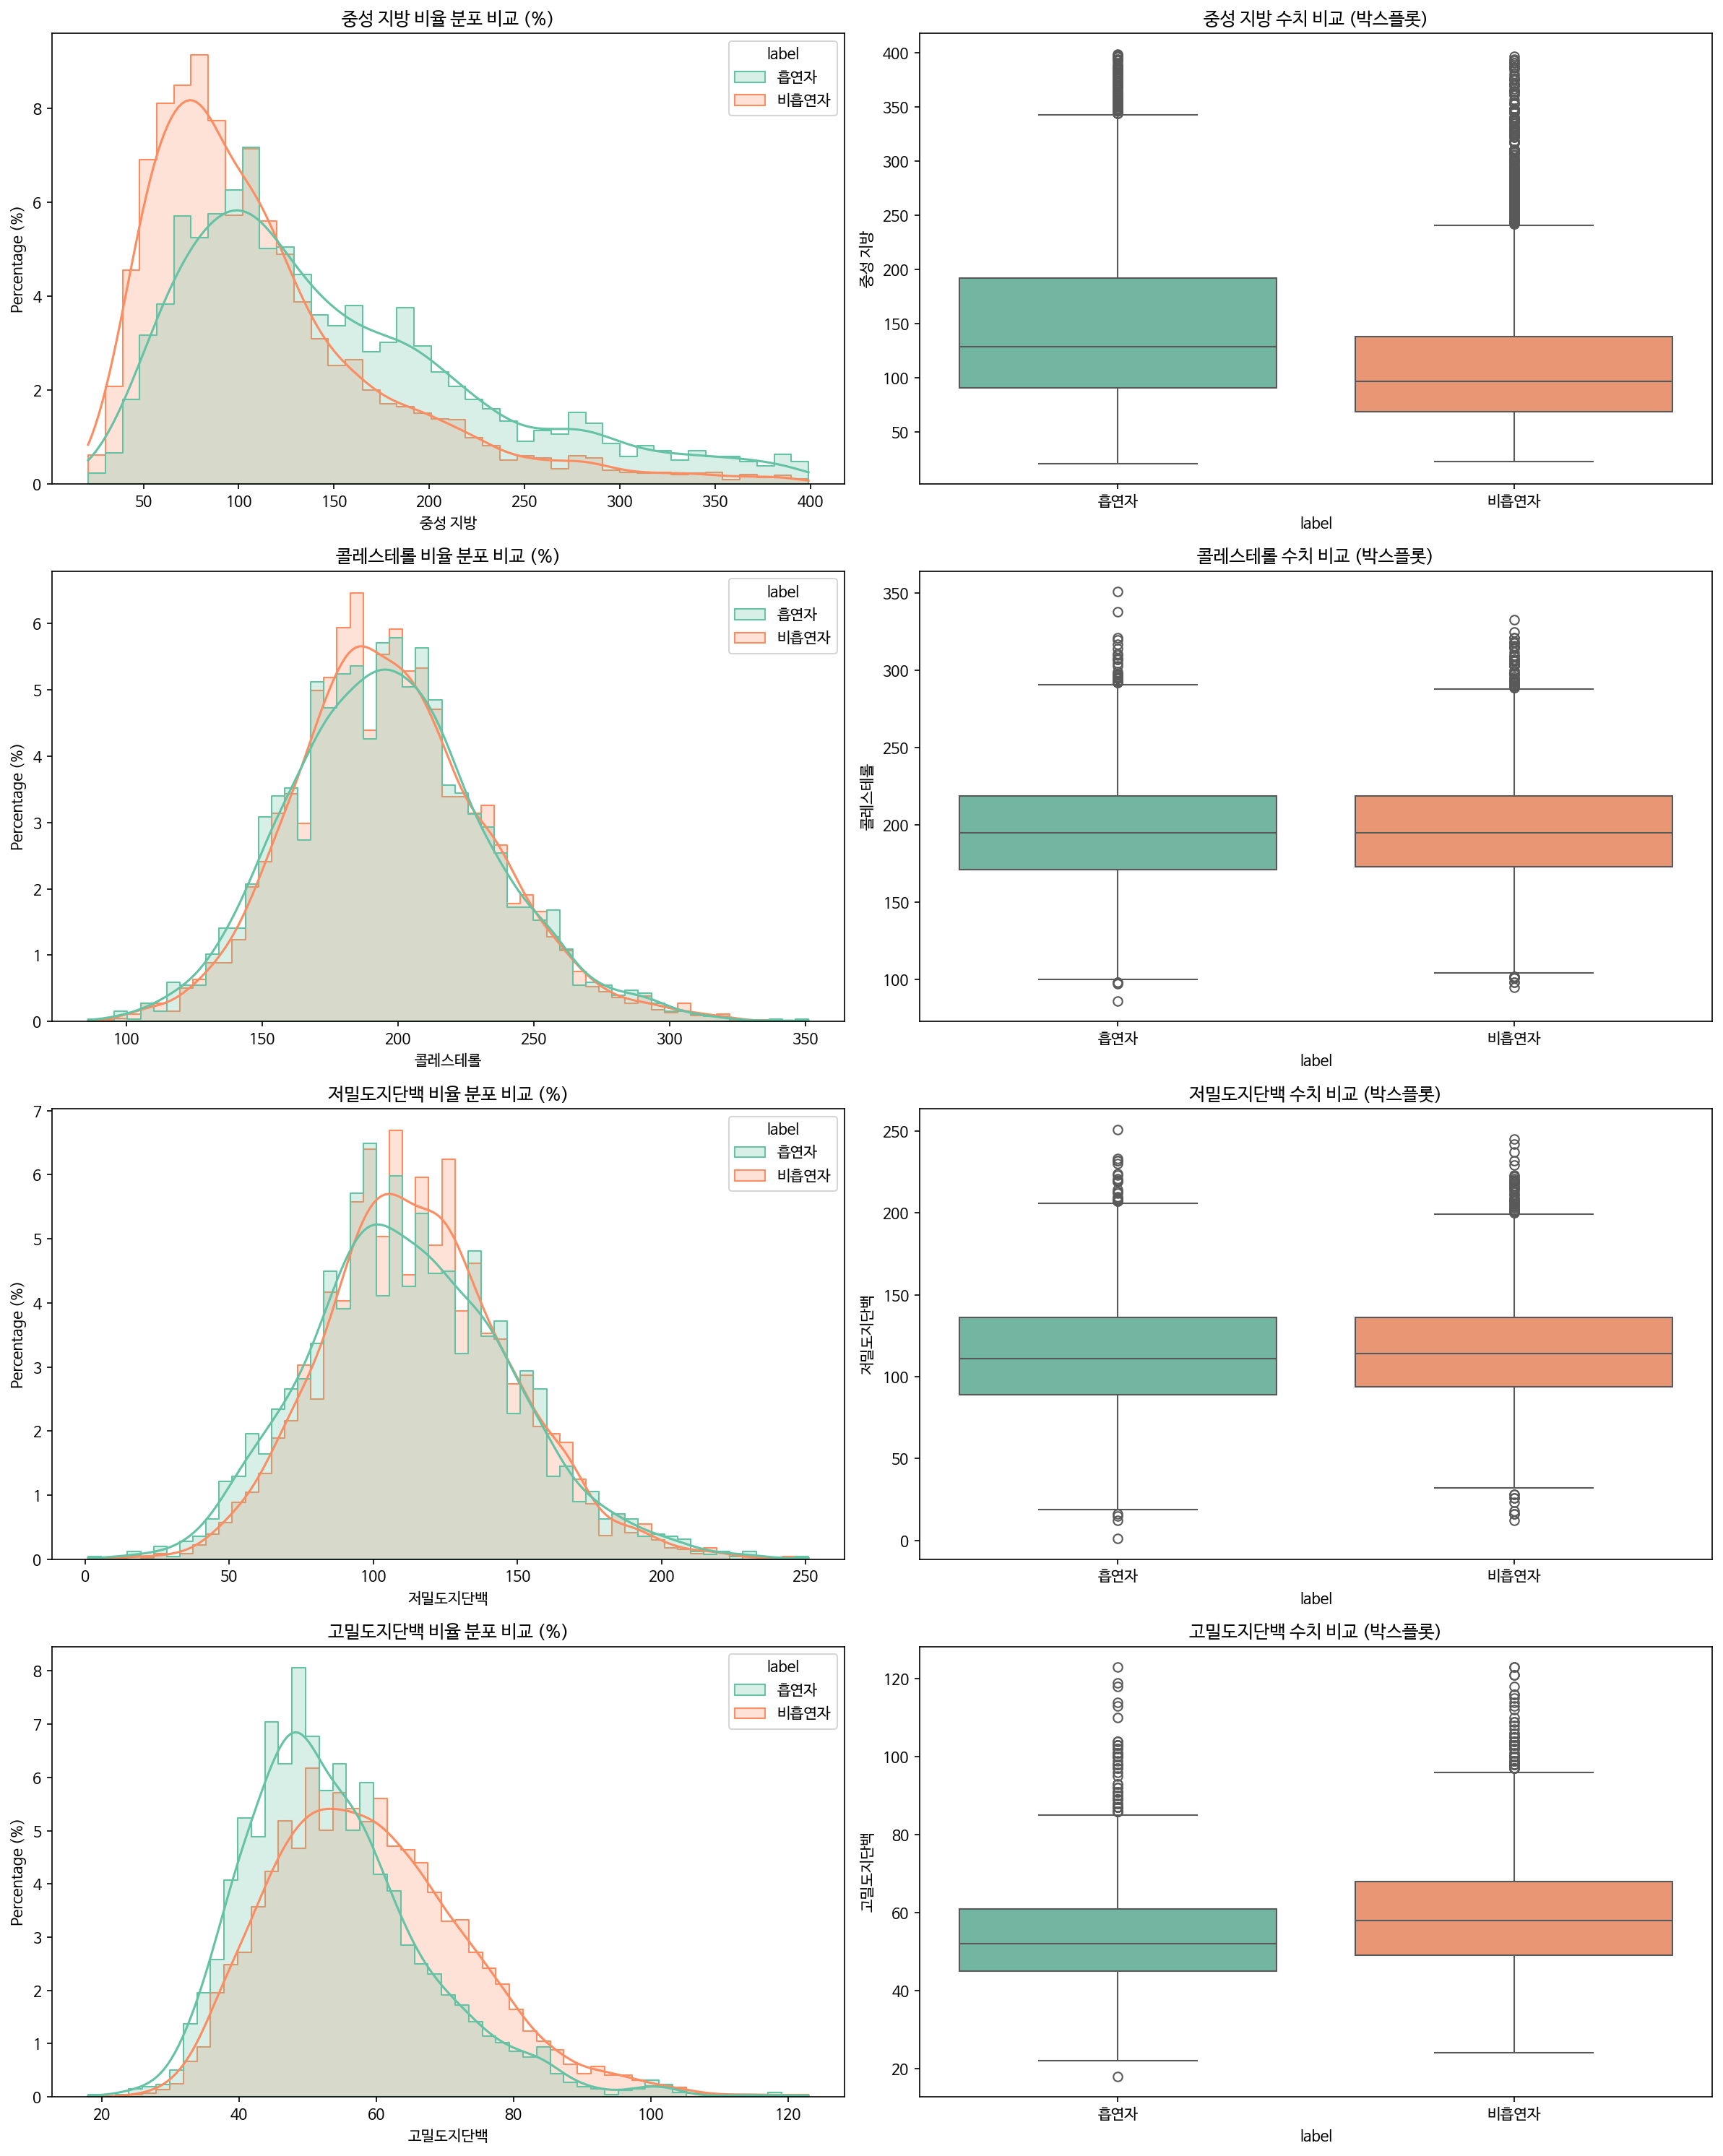

In [39]:
# nomalize 한 것
# 분석할 지표 리스트
target_metrics = ['중성 지방', '콜레스테롤', '저밀도지단백', '고밀도지단백']
label_map = {0: '비흡연자', 1: '흡연자'}

# 4행 2열 레이아웃 설정
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, metric in enumerate(target_metrics):
    # 1. 정규화된 히스토그램 (Percent)
    sns.histplot(data=health_data_cleaned, x=metric, hue=health_data_cleaned['label'].map(label_map),
                 kde=True, element='step', stat='percent', common_norm=False, ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'{metric} 비율 분포 비교 (%)')
    axes[i, 0].set_ylabel('Percentage (%)')

    # 2. 박스플롯
    sns.boxplot(data=health_data_cleaned, x=health_data_cleaned['label'].map(label_map), y=metric,
                hue=health_data_cleaned['label'].map(label_map), palette='Set2', ax=axes[i, 1], legend=False)
    axes[i, 1].set_title(f'{metric} 수치 비교 (박스플롯)')

plt.tight_layout()
plt.show()

In [ ]:
### 이변량 분석에서 파악한 내용을 정리해보세요.
# 충치, 헤모글로빈, 간 효소율, 지질혈액검사(중성 지방, 콜레스테롤, LDL, HDL) 모두 흡연자와 비흡연자간의 P-value가 유의미한 차이를 가지고 있어서 분석을 해볼 이유가 충분하다

추가적으로 각 건강 지표 간의 관계도 이해해봅시다!
예를 들어, BMI, 혈압, 혈당, 콜레스테롤 등의 수치형 변수들은 서로 영향을 주고받을 수 있으며, 이를 통해 건강 상태를 종합적으로 이해하거나, 향후 모델 설계 및 연구 방향을 제안할 수 있습니다.
추가적인 인사이트를 얻어볼까요 ?

### 상관계수를 구하고 HeatMap으로 시각화 후 분석을 해보세요.
- Heatmap: 변수 간의 상관관계(Correlation)를 색상으로 쉽게 확인할 수 있는 시각화 방법입니다.
- 해석 기준:
  - 값이 1에 가까울수록 → 강한 양의 상관관계
  - 값이 -1에 가까울수록 → 강한 음의 상관관계
  - 값이 0에 가까울수록 → 관계가 약함

이를 통해 변수 간 관계를 한눈에 비교하고, 분석에 필요한 주요 변수를 파악할 수 있습니다.

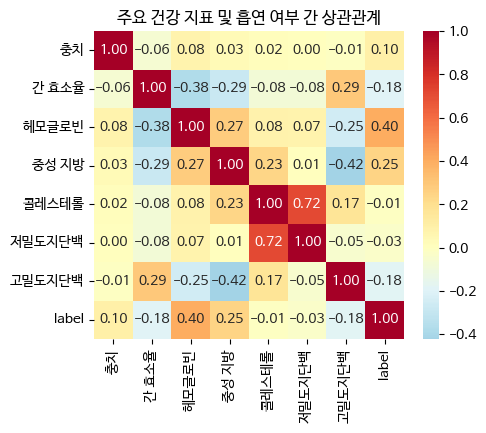

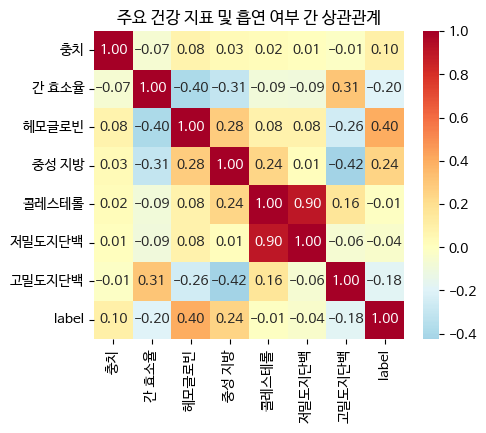

In [ ]:
# 데이터 로드 (경로는 본인의 환경에 맞게 확인이 필요합니다)
try:
    # 분석하고자 하는 주요 변수 선택
    selected_cols = ['충치', '간 효소율', '헤모글로빈','중성 지방','콜레스테롤','저밀도지단백','고밀도지단백','label']
    corr_matrix = health_data[selected_cols].corr()

    # 히트맵 시각화
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
    plt.title('주요 건강 지표 및 흡연 여부 간 상관관계')
    plt.show()
except Exception as e:
    print(f'데이터를 불러오는 중 오류가 발생했습니다: {e}')

# 이상치 제거
try:
    # 분석하고자 하는 주요 변수 선택
    selected_cols = ['충치', '간 효소율', '헤모글로빈','중성 지방','콜레스테롤','저밀도지단백','고밀도지단백','label']
    corr_matrix_cleaned = health_data_cleaned[selected_cols].corr()

    # 히트맵 시각화
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_matrix_cleaned, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
    plt.title('주요 건강 지표 및 흡연 여부 간 상관관계')
    plt.show()
except Exception as e:
    print(f'데이터를 불러오는 중 오류가 발생했습니다: {e}')

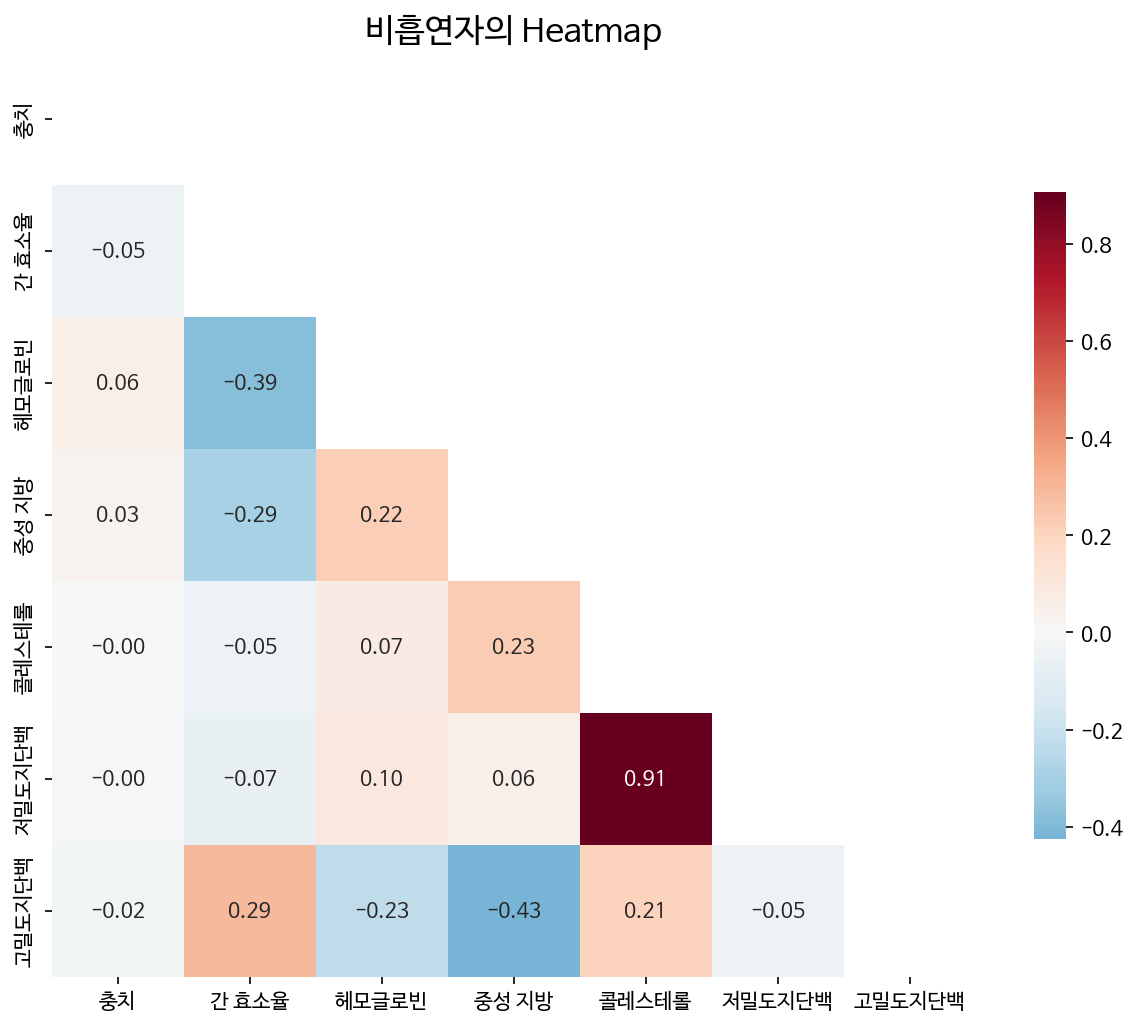

In [40]:
health_data_cleanded_L=health_data_cleaned.groupby('label')[['충치', '간 효소율', '헤모글로빈','중성 지방','콜레스테롤','저밀도지단백','고밀도지단백']]
corr = health_data_cleanded_L.corr()
corr_non= corr.loc[0]
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_non, dtype=bool))
sns.heatmap(corr_non,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            mask=mask,
            center=0,
            square=True,
            cbar_kws={'shrink': 0.7})
plt.title('비흡연자의 Heatmap', fontsize=16)
plt.show()

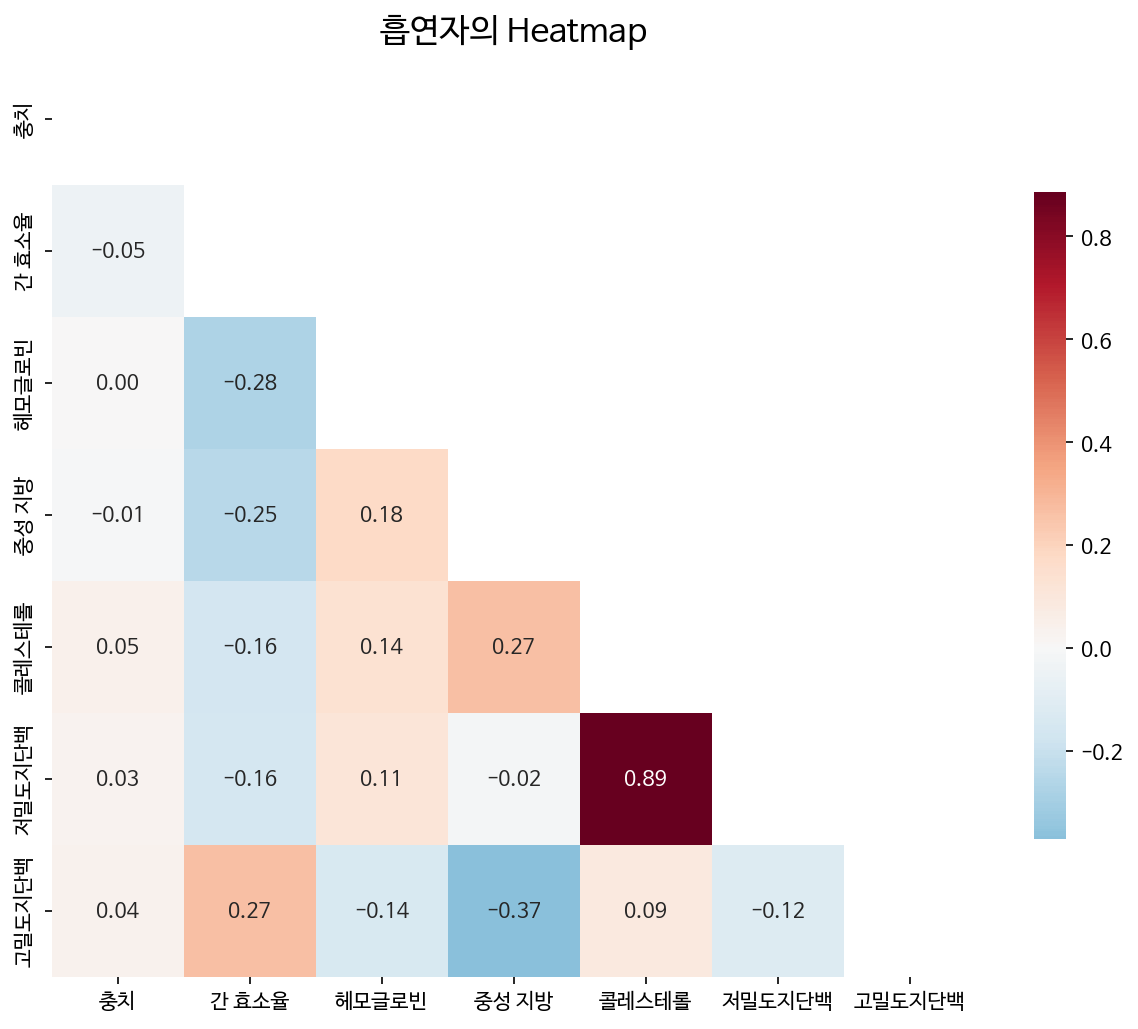

In [41]:
health_data_cleanded_L=health_data_cleaned.groupby('label')[['충치', '간 효소율', '헤모글로빈','중성 지방','콜레스테롤','저밀도지단백','고밀도지단백']]
corr = health_data_cleanded_L.corr()
corr_non= corr.loc[1]
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_non, dtype=bool))
sns.heatmap(corr_non,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            mask=mask,
            center=0,
            square=True,
            cbar_kws={'shrink': 0.7})
plt.title('흡연자의 Heatmap', fontsize=16)
plt.show()

## 5. 관계 정리
- 강한 관계의 변수
- 약한 관계의 변수

In [ ]:
### 강한 관계를 보이는 변수에는 어떤 것이 있나요 ?
# (콜레스테롤, 저밀도지단백), (흡연, 헤모글로빈)

In [ ]:
### 약한 관계를 보이는 변수에는 어떤 것이 있나요 ?
# (충치-콜레스테롤, 중성지방, 저밀도지단백, 고밀도지단백), (중성지방, 저밀도지단백), (콜레스테롤, label), (저밀도지단백, label)

## 5. 결론 도출
어떤 요인이 흡연 여부와 관련성이 높은지 인사이트 제시

예시)
- 흡연자는 비흡연자에 비해 평균 혈압과 중성지방 수치가 유의하게 높았습니다.(p<0.05)
- 반면, BMI는 유의한 차이가 없었습니다. (p>0.05)
- 따라서 흡연은 대사 관련 지표(혈압, 중성지방)에 더 큰 영향을 미치는 것으로 해석할 수 있습니다.

<가설 1>

기존 연구[1]를 바탕으로 설정한 가설을 현 데이터에 적용하여 분석한 결과 두 변수 간 상관계수는 0.1 수준으로 낮게 나타났다. 이는 두 변수 간 강한 상관관계는 존재하지 않음을 의미한다.

그러나 p-value < 0.05로 나타나 통계적으로 유의미한 결과를 보였으며, 따라서 두 변수 사이에는 약한 수준의 양의 상관관계가 존재하며 일정한 경향성이 있음을 확인할 수 있었다.

<가설 2>

흡연 여부와 헤모글로빈 수치 간의 관계를 분석한 결과 상관계수는 0.4로 나타나 중간 수준의 양의 상관관계를 보였다.

또한 p-value < 0.05로 나타나 통계적으로 유의미한 결과가 확인되었다.

이는 흡연자가 비흡연자에 비해 헤모글로빈 수치가 상대적으로 높게 나타나는 경향이 있으며, 흡연이 혈액 내 산소 운반 능력과 관련된 지표에 영향을 미칠 가능성을 시사한다.[2]

<가설 3>

흡연 여부와 간 효소율 간의 상관관계를 분석한 결과 상관계수는 -0.20으로 나타나 약한 음의 상관관계를 보였다.

일반적으로 흡연은 간 기능에 부정적인 영향을 미쳐 간 효소 수치 상승과 관련된 것으로 보고된 연구가 많다.[3]

그러나 본 데이터에서는 반대로 간 효소율이 감소하는 경향이 나타났으며 이는 다음과 같은 가능성을 고려할 수 있다.

데이터 대상자들이 운동이나 건강관리 행동을 병행했을 가능성

약물 복용 또는 건강관리 프로그램 참여

데이터 특성상 표본 구성의 편향

또한 p-value < 0.05로 통계적으로 유의미한 결과가 나타났기 때문에 본 데이터에서는 흡연과 간 효소율 사이에 약한 음의 관계가 존재할 가능성을 확인할 수 있었다.

<가설 4>

흡연 여부와 지질혈액검사 지표 간의 관계를 분석한 결과 중성지방(Triglycerides)의 경우 흡연자 집단에서 수치가 높아지는 경향이 나타나 흡연과 약한 양의 관계가 존재하는 것으로 확인되었다.[4][5]

반면 총 콜레스테롤, 고밀도지단백(HDL)[6], 저밀도지단백(LDL) 등 다른 콜레스테롤 관련 지표에서는 뚜렷한 상관관계가 확인되지 않았다.

결론 - 본 연구에서는 흡연 여부가 다양한 건강 지표에 미치는 영향을 분석하기 위해 상관분석, t-test, 카이제곱 검정 등을 활용하여 데이터를 분석하였다. 분석 결과 흡연은 일부 건강 지표와 통계적으로 유의미한 관계를 가지는 것으로 확인되었다.

특히 흡연과 헤모글로빈 수치 사이에서는 비교적 높은 수준의 양의 상관관계가 나타났으며, 이는 흡연이 혈액 내 산소 운반과 관련된 지표에 영향을 줄 수 있음을 시사한다. 또한 중성지방 수치 역시 흡연자 집단에서 상대적으로 높게 나타나 흡연이 지질 대사에 영향을 미칠 가능성을 확인할 수 있었다.

반면 간 효소율의 경우 기존 연구에서 제시된 경향과 달리 흡연과 약한 음의 상관관계가 나타났으며, 이는 데이터 특성이나 대상자의 생활습관, 건강관리 행동 등의 다양한 요인이 복합적으로 작용했을 가능성을 고려할 수 있다.

또한 지질혈액검사 상태를 기준으로 카이제곱 검정을 수행한 결과 흡연 여부와 지질 상태 사이에는 **통계적으로 유의한 관계(p-value < 0.05)**가 존재하는 것으로 나타났으며, 흡연자 집단에서 지질 위험군의 비율이 더 높게 나타나는 경향을 확인할 수 있었다.

종합적으로 볼 때 흡연은 일부 혈액 지표와 지질 관련 건강 지표에 영향을 미칠 가능성이 있으며, 이는 장기적으로 심혈관 질환 및 대사 질환 위험 증가와 관련될 수 있음을 시사한다. 다만 본 연구는 제한된 변수와 데이터 범위 내에서 수행되었기 때문에 향후에는 식습관, 운동 습관, 연령대, 체질량지수(BMI) 등의 추가적인 요인을 함께 고려한 확장된 분석이 필요할 것으로 판단된다.

[1] Wu, J., Li, M., & Huang, R. (2019). The effect of smoking on caries-related microorganisms. Tobacco induced diseases, 17, 32. https://doi.org/10.18332/tid/105913

[2] Malenica, M., Prnjavorac, B., Bego, T., Dujic, T., Semiz, S., Skrbo, S., Gusic, A., Hadzic, A., & Causevic, A. (2017). Effect of Cigarette Smoking on Haematological Parameters in Healthy Population. Medical archives (Sarajevo, Bosnia and Herzegovina), 71(2), 132–136. https://doi.org/10.5455/medarh.2017.71.132-136

[3] Wannamethee, S. G., & Shaper, A. G. (2010). Cigarette smoking and serum liver enzymes: the role of alcohol and inflammation. Annals of clinical biochemistry, 47(Pt 4), 321–326. https://doi.org/10.1258/acb.2010.009303

[4] Jain, R. B., & Ducatman, A. (2018). Associations between smoking and lipid/lipoprotein concentrations among US adults aged ≥20 years. Journal of Circulating Biomarkers, 7(1). https://doi.org/10.33393/jcb.2018.2089

[5] La Paglia, Laura, Listì, Angela, Caruso, Stefano, Amodeo, Valeria, Passiglia, Francesco, Bazan, Viviana, Fanale, Daniele, Potential Role of ANGPTL4 in the Cross Talk between Metabolism and Cancer through PPAR Signaling Pathway, PPAR Research, 2017, 8187235, 15 pages, 2017. https://doi.org/10.1155/2017/8187235

[6] Kohei Takata, Satoshi Imaizumi, Emi Kawachi, Yasunori Suematsu, Tomohiko Shimizu, Satomi Abe, Yoshino Matsuo, Hitomi Tsukahara, Keita Noda, Eiji Yahiro, Bo Zhang, Yoshinari Uehara, Shin-ichiro Miura, Keijiro Saku, Impact of Cigarette Smoking Cessation on High-Density Lipoprotein Functionality, Circulation Journal, 2014, Volume 78, Issue 12, Pages 2955-2962, Released on J-STAGE November 25, 2014, Advance online publication October 16, 2014, Online ISSN 1347-4820, Print ISSN 1346-9843, https://doi.org/10.1253/circj.CJ-14-0638